In [12]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image
import os

# Import the model analysis module
from model import Predictor, FeatureMapExtractor, GradCAM
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.resnet50 import preprocess_input

print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")
print("\n✓ All imports successful")

TensorFlow version: 2.21.0
NumPy version: 2.2.6

✓ All imports successful


In [13]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    GlobalAveragePooling2D,
    Dropout,
    Dense
)
from tensorflow.keras.applications import ResNet50

NUM_CLASSES = 5
inputs = Input(shape=(256,256,3))
base_model = ResNet50(
    include_top=False,
    weights=None,   # không lấy ImageNet nữa
    input_tensor=inputs)
x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.5)(x)
x = Dense(1024, activation="relu")(x)
x = Dropout(0.5)(x)
outputs = Dense(
    NUM_CLASSES,
    activation="softmax",
    name="final_output"
)(x)
model = Model(inputs, outputs)
model.load_weights("Resnet50_best\model.weights.h5")

In [14]:
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 262, 262,  │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_3_c

 Total params: 25,691,013 (98.00 MB)

 Trainable params: 25,637,893 (97.80 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [15]:
from model.predict import *
from model.feature_map import *
from model.gradcam import *
predictor = Predictor(model)

extractor = FeatureMapExtractor(model)

gradcam = GradCAM(model)

In [16]:
# =========================
# Load image
# =========================

image = tf.keras.utils.load_img("diabetic-retinopathy.jpg", target_size=(256,256))
image = tf.keras.utils.img_to_array(image)

# Keep original image for visualization
original_image = image.copy()
# ResNet50 preprocessing
image = preprocess_input(image)


# =========================
# Prediction
# =========================

predictor = Predictor(model)
prediction = predictor.predict(image)

probabilities = prediction[0]
predicted_class = np.argmax(probabilities)

print("Prediction:")
print("Class:", predicted_class)
print("Probability:", probabilities)
print("Confidence:", probabilities[predicted_class])

Prediction:
Class: 2
Probability: [0.26001614 0.11571403 0.40652904 0.08229885 0.13544196]
Confidence: 0.40652904


In [17]:
# =========================
# Create extractor
# =========================

extractor = FeatureMapExtractor(
    model
)


# Show layers
extractor.show_layers()

Index   Layer Name                         Type                     Output Shape
----------------------------------------------------------------------------------------------------
0       input_layer_3                      InputLayer               (None, 256, 256, 3)
1       conv1_pad                          ZeroPadding2D            (None, 262, 262, 3)
2       conv1_conv                         Conv2D                   (None, 128, 128, 64)
3       conv1_bn                           BatchNormalization       (None, 128, 128, 64)
4       conv1_relu                         Activation               (None, 128, 128, 64)
5       pool1_pad                          ZeroPadding2D            (None, 130, 130, 64)
6       pool1_pool                         MaxPooling2D             (None, 64, 64, 64)
7       conv2_block1_1_conv                Conv2D                   (None, 64, 64, 64)
8       conv2_block1_1_bn                  BatchNormalization       (None, 64, 64, 64)
9       conv2_block1_1_re

(8, 8, 2048)


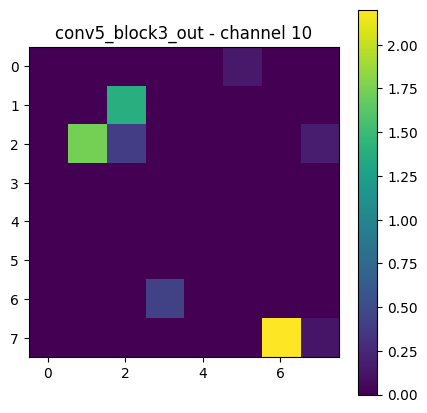

In [ ]:
layer_name = "conv2_block1_out"
feature_map = extractor.extract_layer(image, layer_name)


print(feature_map.shape)
channel = 10
plt.figure(figsize=(5,5))
plt.imshow(feature_map[:,:,channel], cmap="viridis")
plt.title(f"{layer_name} - channel {channel}")
plt.colorbar()
plt.show()

In [19]:
# =========================
# Create GradCAM
# =========================

gradcam = GradCAM(model)
gradcam.show_layers()

Index   Layer Name                         Type                     Output Shape
----------------------------------------------------------------------------------------------------
0       input_layer_3                      InputLayer               (None, 256, 256, 3)
1       conv1_pad                          ZeroPadding2D            (None, 262, 262, 3)
2       conv1_conv                         Conv2D                   (None, 128, 128, 64)
3       conv1_bn                           BatchNormalization       (None, 128, 128, 64)
4       conv1_relu                         Activation               (None, 128, 128, 64)
5       pool1_pad                          ZeroPadding2D            (None, 130, 130, 64)
6       pool1_pool                         MaxPooling2D             (None, 64, 64, 64)
7       conv2_block1_1_conv                Conv2D                   (None, 64, 64, 64)
8       conv2_block1_1_bn                  BatchNormalization       (None, 64, 64, 64)
9       conv2_block1_1_re

(256, 256)


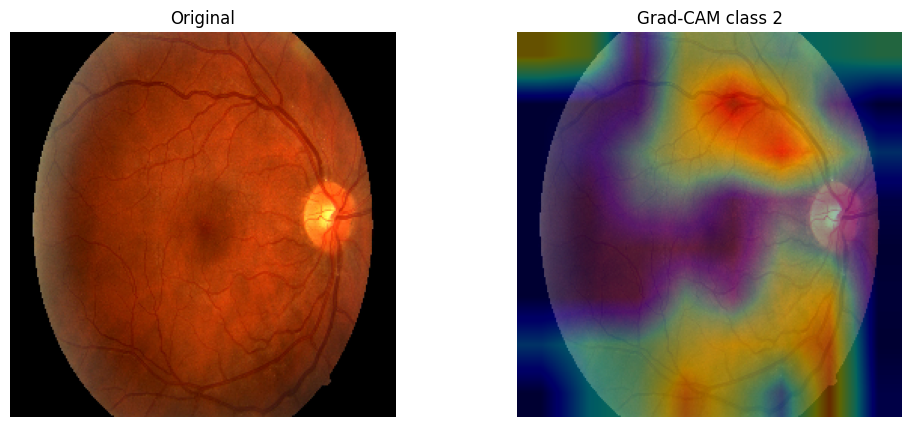

In [ ]:
heatmap = gradcam.generate(
    image,
    layer_name="conv5_block3_out",
    target_class=predicted_class #Đây là chỉ số class của model. Tập trung nhìn ở đâu để predict ra class 0 1 2 3 4, mỗi cái sẽ có map khác nhau
)


print(heatmap.shape)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(original_image.astype("uint8"))
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(original_image.astype("uint8"))
plt.imshow(heatmap, cmap="jet", alpha=0.4)

plt.title(f"Grad-CAM class {predicted_class}")
plt.axis("off")

plt.show()